Templates saved:
../data/xi_bao_template.txt
../data/xi_nowiggle_template.txt


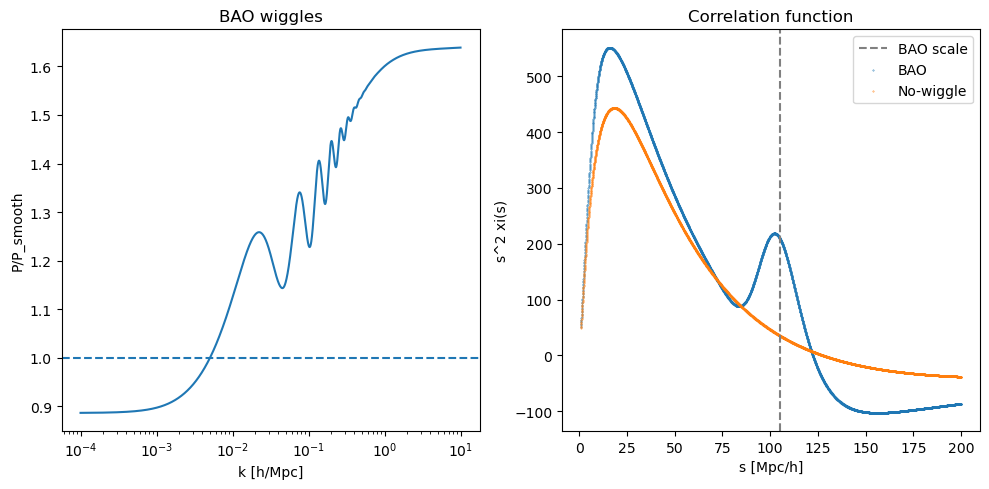

In [25]:
import numpy as np
import camb
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

def pk_nowiggle_eh(k, H0, ombh2, omch2, ns):
    """
    Eisenstein & Hu 1998 no-wiggle power spectrum
    k: 1D array in h/Mpc
    H0: Hubble parameter [km/s/Mpc]
    ombh2, omch2: baryon and CDM densities
    ns: spectral index
    Returns: P_nw(k) in arbitrary units (can be normalized later)
    """

    h = H0 / 100.0
    Omega_b = ombh2 / h**2
    Omega_c = omch2 / h**2
    Omega_m = Omega_b + Omega_c

    f_b = Omega_b / Omega_m
    f_c = Omega_c / Omega_m

    # EH shape parameter
    theta = 2.725/2.7  # CMB temperature factor
    s = 44.5 * np.log(9.83/Omega_m*h) / np.sqrt(1 + 10*(Omega_b*h**2)**0.75)  # sound horizon, Mpc NOT USED

    # Scaled wavenumber (EQ. 28)
    q = k * theta**2 / (Omega_m*h**2) 

    # Alpha_c and beta_c (CDM transfer function) (EQs. 11-12)
    alpha_c = (1 - 0.328*np.log(431*Omega_m*h**2)*Omega_b/Omega_m + 
               0.38*np.log(22.3*Omega_m*h**2)*(Omega_b/Omega_m)**2)
    beta_c = 1 / (1 + 0.2*(Omega_c*h**2)**0.5)

    # CDM no-wiggle transfer function (EQ. 29)
    L0 = np.log(2*np.e + 1.8*beta_c*q)
    C0 = 14.2 + 731/(1 + 62.5*q)
    Tc_nw = L0 / (L0 + C0*q**2)

    # Baryon no-wiggle transfer function
    Tb_nw = Tc_nw  # for no-wiggle, baryons follow CDM approximately

    # Combine weighted by fractions
    T_nw = f_b * Tb_nw + f_c * Tc_nw

    # Power spectrum (arbitrary normalization)
    P_nw = k**ns * T_nw**2

    return P_nw

# ============================================================
# 1. Main function
# ============================================================

def generate_templates(
    z=0.0,
    H0=67.3,
    ombh2=0.022,
    omch2=0.119,
    ns=0.96,
    kmax=10.0,
    nk=8000,
    smin=1.0,
    smax=200.0,
    n_s=5000,
    smooth_factor_ratio=0.0005,
    Sigma_nl=5.0,              # BAO damping scale [Mpc/h]
    save_path="../data/",
    plot=True
):
    """
    Generate real-space BAO templates ξ(s) and ξ_nowiggle(s)
    """

    # -------------------------------------------------
    # 1. CAMB linear P(k)
    # -------------------------------------------------
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns)
    pars.set_matter_power(redshifts=[z], kmax=kmax)

    results = camb.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(
        minkh=1e-4,
        maxkh=kmax,
        npoints=nk
    )
    pk = pk[0]*15.

    # -------------------------------------------------
    # 2. Smooth (no-wiggle) P(k)
    # -------------------------------------------------
    # logk = np.log(k)
    # logpk = np.log(pk)

    # s_spline = smooth_factor_ratio * len(k)
    # spline = UnivariateSpline(logk, logpk, s=s_spline, k=3)

    # pk_smooth = np.exp(spline(logk))

    # -------------------------------------------------
    # 2. No-wiggle P(k) from EH
    # -------------------------------------------------
    pk_smooth = pk_nowiggle_eh(k, H0, ombh2, omch2, ns)

    # Match EH P_nw amplitude to CAMB at large scales
    k_match = (k > .00001) & (k < .05)  # adjust if needed
    norm_factor = np.mean(pk[k_match] / pk_smooth[k_match])
    pk_smooth *= norm_factor

    # -------------------------------------------------
    # 3. BAO damping
    # -------------------------------------------------
    damping = np.exp(-k**2 * Sigma_nl**2 / 2)

    pk_bao = pk_smooth + (pk - pk_smooth) * damping
    pk_nw  = pk_smooth

    # -------------------------------------------------
    # 4. Fourier transform → ξ(s)
    # -------------------------------------------------
    s_arr = np.linspace(smin, smax, n_s)

    xi_bao = []
    xi_nw  = []

    # mild high-k cutoff to stabilize integral
    k_cut = 5.0
    window = np.exp(-(k / k_cut)**2)
    #window = 1

    for r in s_arr:
        sinc = np.sin(k * r) / (k * r)

        integrand_bao = k**2 * pk_bao * window * sinc
        integrand_nw  = k**2 * pk_nw  * window * sinc

        xi_bao.append(np.trapezoid(integrand_bao, k) / (2 * np.pi**2))
        xi_nw.append(np.trapezoid(integrand_nw,  k) / (2 * np.pi**2))

    xi_bao = np.array(xi_bao)
    xi_nw  = np.array(xi_nw)

    # -------------------------------------------------
    # 5. Save
    # -------------------------------------------------
    np.savetxt(save_path + "xi_bao_template.txt", np.c_[s_arr, xi_bao])
    np.savetxt(save_path + "xi_nowiggle_template.txt", np.c_[s_arr, xi_nw])

    print("Templates saved:")
    print(save_path + "xi_bao_template.txt")
    print(save_path + "xi_nowiggle_template.txt")

    # -------------------------------------------------
    # 6. Diagnostics
    # -------------------------------------------------
    if plot:
        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.semilogx(k, pk / pk_smooth)
        plt.axhline(1, linestyle='--')
        plt.xlabel("k [h/Mpc]")
        plt.ylabel("P/P_smooth")
        plt.title("BAO wiggles")

        plt.subplot(1,2,2)
        plt.axvline(105, linestyle='--', color='gray', label="BAO scale")
        plt.scatter(s_arr, xi_bao * s_arr**2, label="BAO", s=.1)
        plt.scatter(s_arr, xi_nw  * s_arr**2, label="No-wiggle", s=.1)
        plt.xlabel("s [Mpc/h]")
        plt.ylabel("s^2 xi(s)")
        plt.legend()
        plt.title("Correlation function")

        plt.tight_layout()
        plt.show()

    return s_arr, xi_bao, xi_nw


# ============================================================
# 2. Run directly
# ============================================================

if __name__ == "__main__":

    generate_templates(
        z=0.0,          # Multidark snapshot
        Sigma_nl=5.0,   
        plot=True
    )


=== BAO FIT RESULTS ===
alpha  = 1.0011
B      = 0.2761
Sigma  = 6.0000
A0, A1, A2 = 0.0003, -0.0343, -0.0007



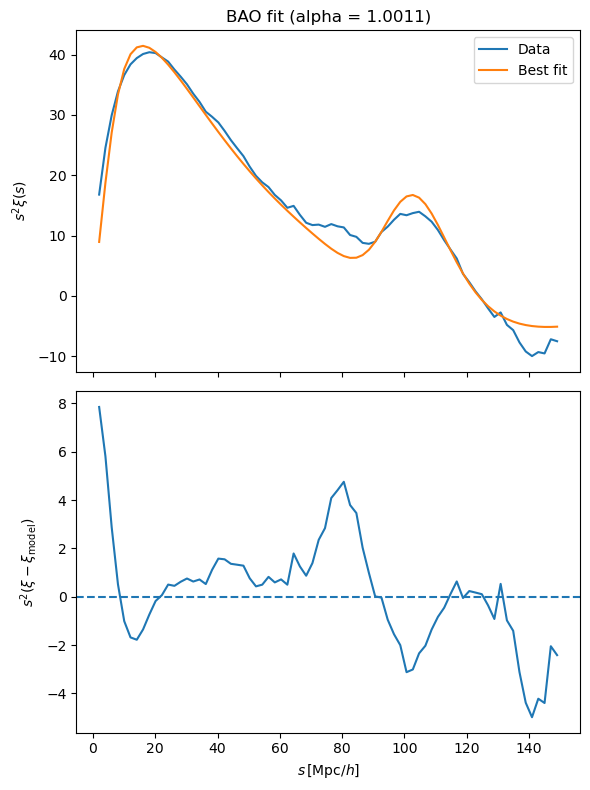

In [29]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# ============================================================
# 1. Load monopole (your pipeline output)
# ============================================================

def load_monopole(filename):
    data = np.load(filename)
    return data['s'], data['xi0']


# ============================================================
# 2. Load BAO templates (precomputed)
# ============================================================

def load_templates(path_bao, path_nw):
    s_w, xi_w = np.loadtxt(path_bao, unpack=True)
    s_nw, xi_nw = np.loadtxt(path_nw, unpack=True)
    return s_w, xi_w, xi_nw


# ============================================================
# 3. BAO model
# ============================================================

def xi_model(s, params, s_temp, xi_w, xi_nw):
    alpha, B, Sigma, A0, A1, A2 = params

    interp_w = interp1d(s_temp, xi_w, kind='linear', fill_value="extrapolate")
    interp_nw = interp1d(s_temp, xi_nw, kind='linear', fill_value="extrapolate")

    s_scaled = alpha * s
    xi_w_scaled  = interp_w(s_scaled)
    xi_nw_scaled = interp_nw(s_scaled)

    bao_term = xi_w_scaled - xi_nw_scaled
    #damping  = np.exp(-s_scaled**2 / (2 * Sigma**2))  # s unscaled
    xi_mod = B**2 * (xi_nw_scaled + bao_term) + A0 + A1/s + A2/s**2

    return xi_mod


# ============================================================
# 4. Chi^2 (no covariance yet)
# ============================================================

def chi2(params, s, xi, s_temp, xi_w, xi_nw):
    model = xi_model(s, params, s_temp, xi_w, xi_nw)
    chi2 = np.sum((xi - model)**2)
    return chi2


# ============================================================
# 5. Fit function
# ============================================================

def fit_bao(s, xi, s_temp, xi_w, xi_nw, fit_range=(70,150)):

    mask = (s >= fit_range[0]) & (s <= fit_range[1])
    s_fit  = s[mask]
    xi_fit = xi[mask]

    p0 = [1.0, 1.0, 6.0, 0.0, 0.0, 0.0]  # alpha, B, Sigma, A0, A1, A2
    bounds = [
        (0.8, 1.2),   # alpha
        (0, None),    # B
        (0, 20),      # Sigma
        (None, None), # A0
        (None, None), # A1
        (None, None)  # A2
    ]

    result = minimize(
        chi2,
        p0,
        args=(s_fit, xi_fit, s_temp, xi_w, xi_nw),
        method='L-BFGS-B',
        bounds=bounds
    )

    return result


# ============================================================
# 6. Plot results
# ============================================================

def plot_fit(s, xi, result, s_temp, xi_w, xi_nw, title=None):

    xi_best = xi_model(s, result.x, s_temp, xi_w, xi_nw)
    residuals = xi - xi_best

    fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

    # Top: fit
    ax[0].plot(s, xi * s**2, label='Data')
    ax[0].plot(s, xi_best * s**2, label='Best fit')
    ax[0].set_ylabel(r'$s^2 \xi(s)$')
    ax[0].legend()

    if title is not None:
        ax[0].set_title(title)

    # Bottom: residuals
    ax[1].plot(s, residuals * s**2)
    ax[1].axhline(0, linestyle='--')
    ax[1].set_xlabel(r'$s \, [\mathrm{Mpc}/h]$')
    ax[1].set_ylabel(r'$s^2 (\xi - \xi_{\mathrm{model}})$')

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. High-level wrapper (what you actually call)
# ============================================================

def run_bao_fit(
    monopole_file,
    template_bao,
    template_nw,
    fit_range=(70,150)
):

    # Load data
    s, xi = load_monopole(monopole_file)

    # Load templates
    s_temp, xi_w, xi_nw = load_templates(template_bao, template_nw)

    # Fit
    result = fit_bao(s, xi, s_temp, xi_w, xi_nw, fit_range=fit_range)

    # Print result
    print("\n=== BAO FIT RESULTS ===")
    print(f"alpha  = {result.x[0]:.4f}")
    print(f"B      = {result.x[1]:.4f}")
    print(f"Sigma  = {result.x[2]:.4f}")
    print(f"A0, A1, A2 = {result.x[3]:.4f}, {result.x[4]:.4f}, {result.x[5]:.4f}")
    print("=======================\n")

    # Plot
    plot_fit(s, xi, result, s_temp, xi_w, xi_nw,
             title=f"BAO fit (alpha = {result.x[0]:.4f})")

    return result



# ============================================================
if __name__ == "__main__":
    run_bao_fit(
        monopole_file='../data/monopoles/box/mag=-21.2_sep=1.0-150.0_binsep=2.0_full.npz',
        template_bao='../data/xi_bao_template.txt',
        template_nw='../data/xi_nowiggle_template.txt',
        fit_range=(80, 140)
    )


